# Contexte
Une entreprise possède plusieurs bâtiments équipés de capteurs IoT.
Chaque capteur collecte régulièrement des informations sur la température, l'humidité, la pression,
la consommation énergétique, l'état du capteur, le bâtiment, la date et l'heure de la mesure.
Après avoir utilisé NumPy pour manipuler les données numériques et Pandas pour importer,
nettoyer et analyser le dataset, l'étape suivante consiste à représenter graphiquement les
informations afin d'identifier des tendances, des différences entre bâtiments et des anomalies.

In [1]:
# importation des biblio
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# importation des donnes 
df = pd.read_csv("/home/adama/atelier_matplotlib_iot/data/mesures_capteurs.csv", parse_dates=["date_heure"])
df = df.sort_values("date_heure").reset_index(drop=True)
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0001,2026-01-05 00:00:00,C001,B001,24.91,54.60,1019.00,222.33,OK
1,M0002,2026-01-05 01:00:00,C002,B001,18.15,51.98,1014.02,165.77,OK
2,M0003,2026-01-05 02:00:00,C003,B001,23.95,56.47,1020.04,215.00,OK
3,M0004,2026-01-05 03:00:00,C004,B002,26.20,76.27,1016.74,191.33,OK
4,M0005,2026-01-05 04:00:00,C005,B002,27.11,55.41,1020.03,227.75,OK


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_mesure     605 non-null    str           
 1   date_heure    605 non-null    datetime64[us]
 2   id_capteur    605 non-null    str           
 3   batiment      605 non-null    str           
 4   temperature   599 non-null    float64       
 5   humidite      600 non-null    float64       
 6   pression      600 non-null    float64       
 7   consommation  600 non-null    float64       
 8   etat          601 non-null    str           
dtypes: datetime64[us](1), float64(4), str(4)
memory usage: 42.7 KB


# Partie 1 – Graphique linéaire (Line Plot)

## 1) Afficher l'évolution de la température en fonction du temps, avec le titre, les labels, la légende et la grille.

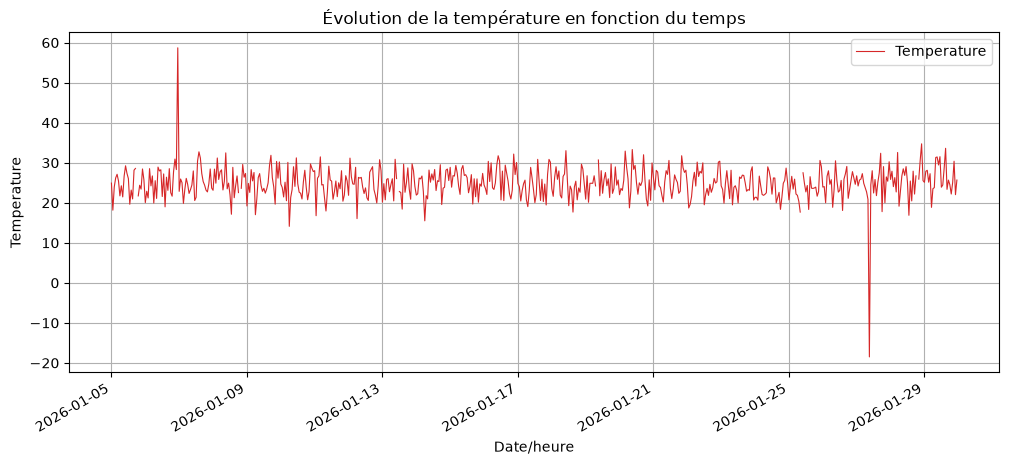

In [4]:
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(df["date_heure"], df["temperature"], color = "tab:red", linewidth=0.8)
ax.set_title("Évolution de la température en fonction du temps")
ax.set_xlabel("Date/heure")
ax.set_ylabel("Temperature")
ax.legend(["Temperature"])
ax.grid(True)
fig.autofmt_xdate()
plt.show()

## 2) Identifier visuellement les valeurs qui semblent anormales.

Le graphique permet d'identifier plusieurs types d'anomalies :

1. **Pics isolés** : des montées soudaines de température.
2. **Creux anormaux** : des chutes abruptes en dehors des variations saisonnières attendues.
3. **Plages de stabilité suspecte** : des périodes où la température reste figée à une même valeur

# Partie 2 – Diagramme en barres (Bar Chart)

## 1) Déterminer consommation_batiment qui stocke les consommations moyennes des bâtiments (en kWh)

In [5]:
consommation_batiment = df.groupby("batiment")["consommation"].mean().sort_index()

consommation_batiment

batiment
B001    177.870927
B002    221.785333
B003    153.191000
B004    282.552282
Name: consommation, dtype: float64

## 2) Comparer graphiquement la consommation moyenne des bâtiments

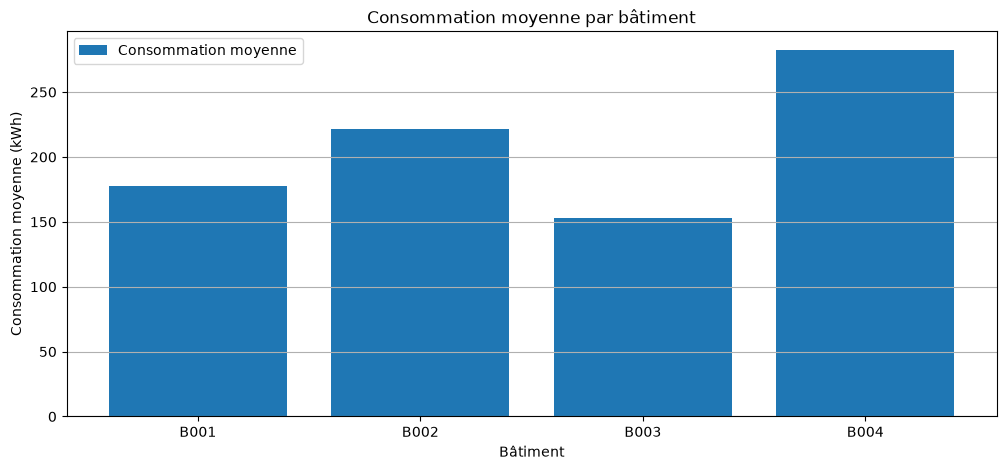

In [6]:
fig, ax = plt.subplots(figsize=(12,5))
ax.bar(consommation_batiment.index, consommation_batiment.values, color="tab:blue")
ax.set_title("Consommation moyenne par bâtiment")
ax.set_xlabel("Bâtiment")
ax.set_ylabel("Consommation moyenne (kWh)")
ax.legend(["Consommation moyenne"])
ax.grid(axis="y")
plt.show()

## 3) Comparer la consommation moyenne des bâtiments avec un graphique horizontal

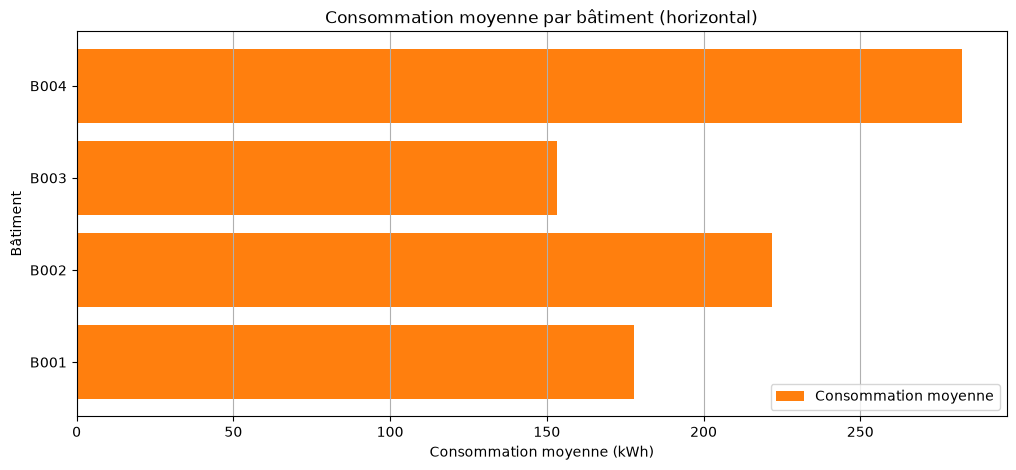

In [7]:
fig, ax = plt.subplots(figsize=(12,5))
ax.barh(consommation_batiment.index, consommation_batiment.values, color="tab:orange")
ax.set_title("Consommation moyenne par bâtiment (horizontal)")
ax.set_xlabel("Consommation moyenne (kWh)")
ax.set_ylabel("Bâtiment")
ax.legend(["Consommation moyenne"])
ax.grid(axis="x")
plt.show()

## 4) Dans quels cas un graphique horizontal peut-il être plus lisible ?

Un graphique horizontal est préféré quand :
- Quand les libellés des catégories sont longs (ils restent horizontaux et lisibles au lieu d'être tournés).
- Quand il y a beaucoup de catégories à comparer (plus facile à lire en liste verticale).
- Quand on veut mettre en avant un classement (les barres horizontales imitent un classement de haut en bas).

# Partie 3 – Histogramme

## 1) Afficher la distribution des températures en divisant la plage des données en 20 classes et en affichant uniquement les lignes horizontales de la grille

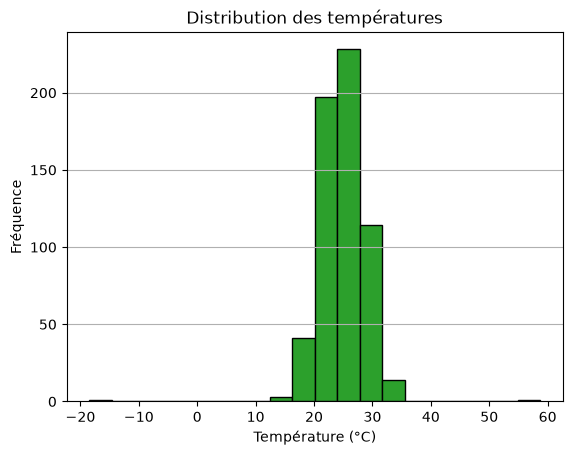

In [8]:
fig, ax = plt.subplots()
ax.hist(df["temperature"].dropna(), bins=20, color="tab:green", edgecolor="black")
ax.set_title("Distribution des températures")
ax.set_xlabel("Température (°C)")
ax.set_ylabel("Fréquence")
ax.grid(axis="y")
plt.show()

## 2) Analyser le graphique pour voir

### a) où se concentrent les températures ;

Les températures se concentrent autour de la valeur médiane (zone centrale de l'histogramme, la plus fournie en effectifs)

### b) si la distribution semble symétrique ;

La distribution semble globalement symétrique, proche d'une forme en cloche (distribution normale). Cela indique que les variations de température s'effectuent de manière équilibrée autour de la moyenne. Une telle symétrie est favorable car elle suggère : pas de biais systématique du capteur, une régulation bien calibrée, et des conditions de fonctionnement relativement stables.

### c) s'il existe des valeurs très éloignées ;

Quelques valeurs isolées apparaissent loin du centre (queues de distribution peu peuplées).

### d) si des valeurs aberrantes sont visibles.

Ces valeurs isolées aux extrémités constituent des valeurs potentiellement aberrantes (outliers). Leur détection est importante pour : identifier les défaillances de capteur, repérer les événements exceptionnels (panne climatisation, travaux d'maintenance), ou purifier les données avant analyse statistique. Une investigation cas-par-cas est recommandée avant d'éliminer ces points.

## 3) Afficher la distribution de la consommation en divisant la plage des données en 20 classes

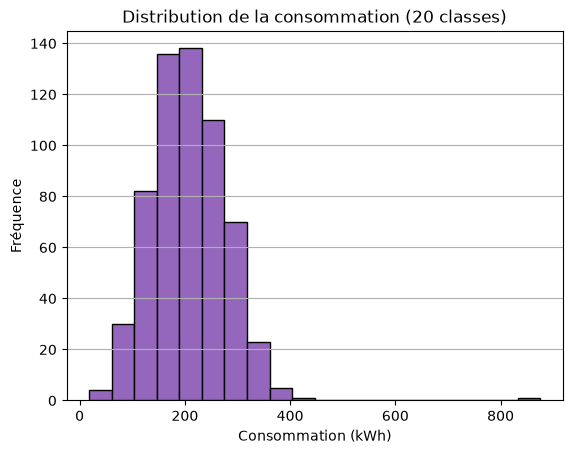

In [9]:
fig, ax = plt.subplots()
ax.hist(df["consommation"].dropna(), bins=20, color="tab:purple", edgecolor="black")
ax.set_title("Distribution de la consommation (20 classes)")
ax.set_xlabel("Consommation (kWh)")
ax.set_ylabel("Fréquence")
ax.grid(axis="y")
plt.show()

### a) Modifier le nombre de classes à 10

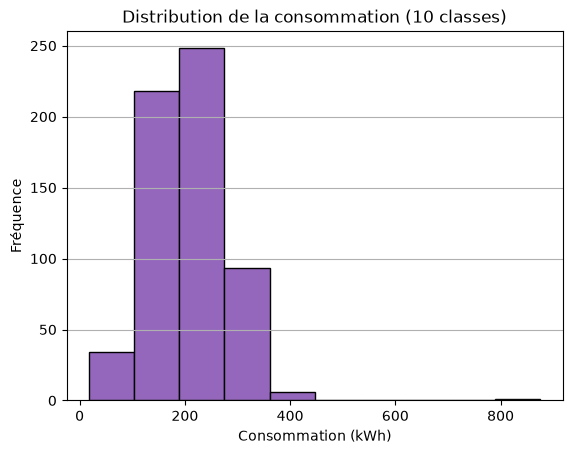

In [10]:
fig, ax = plt.subplots()
ax.hist(df["consommation"].dropna(), bins=10, color="tab:purple", edgecolor="black")
ax.set_title("Distribution de la consommation (10 classes)")
ax.set_xlabel("Consommation (kWh)")
ax.set_ylabel("Fréquence")
ax.grid(axis="y")
plt.show()

### b) Modifier le nombre de classes à 30

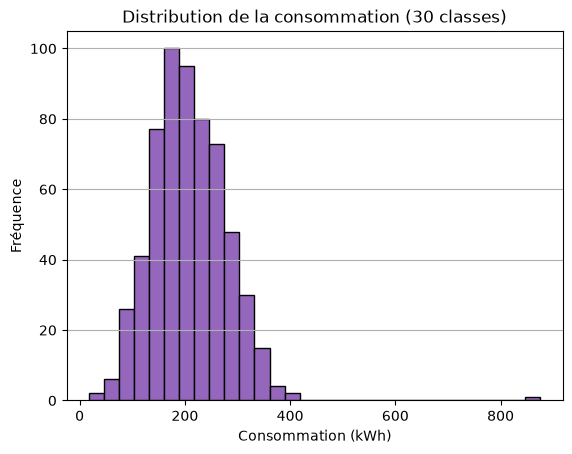

In [11]:
fig, ax = plt.subplots()
ax.hist(df["consommation"].dropna(), bins=30, color="tab:purple", edgecolor="black")
ax.set_title("Distribution de la consommation (30 classes)")
ax.set_xlabel("Consommation (kWh)")
ax.set_ylabel("Fréquence")
ax.grid(axis="y")
plt.show()

### c) Quel impact le nombre de classes a-t-il sur l'interprétation ?

- **Peu de classes (10)** : la distribution paraît plus lisse et régulière. On observe une tendance générale (par ex. une courbe en cloche pour une distribution normale), mais on risque de masquer des structures importantes. Exemple : un pic local d'une classe peut sembler insignifiant, alors qu'il révèle une anomalie réelle.

- **Beaucoup de classes (30)** : on capture davantage de détails et de variations locales, mais le graphique devient très fragmenté et bruyant. Des fluctuations aléatoires peuvent être surinterprétées comme des patterns significatifs. C'est utile pour détecter les multi-modalités (plusieurs pics de consommation à différents niveaux).

- **Bon compromis (20 classes)** : permet de voir à la fois la forme générale (symétrie, asymétrie, queue de distribution) et les variations significatives sans sur-amplifier le bruit. C'est l'idéal pour une première exploration des données.

# Partie 4 – Nuage de points (Scatter Plot)

## 1) Réaliser un nuage de points entre température et consommation

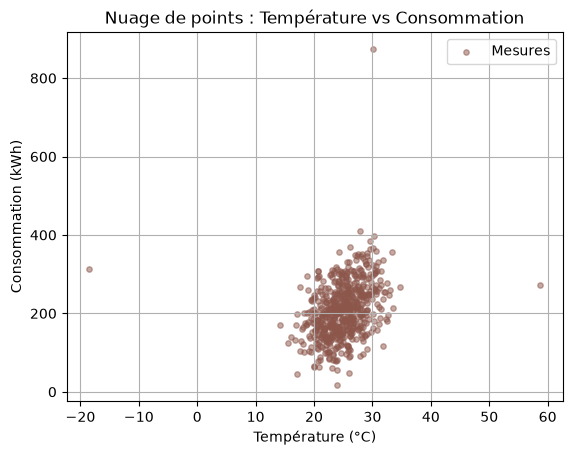

In [12]:
fig, ax = plt.subplots()
ax.scatter(df["temperature"], df["consommation"], alpha=0.5, color="tab:brown", s=15)
ax.set_title("Nuage de points : Température vs Consommation")
ax.set_xlabel("Température (°C)")
ax.set_ylabel("Consommation (kWh)")
ax.legend(["Mesures"])
ax.grid(True)
plt.show()

## 2) Déterminer visuellement s'il semble exister une relation entre les deux

Le nuage de points révèle **l'absence d'une corrélation linéaire nette** entre température et consommation. Observations clés :

1. **Dispersion horizontale** : pour une même température, on observe des consommations très variables, ce qui suggère que la température seule n'explique pas les variations de consommation.

2. **Pas de tendance** : pas de pente visible (positive ou négative), contrairement à ce qu'on attendrait intuitivement (moins froid = moins de chauffage = moins de consommation).



4. **Implication pour la gestion énergétique** : on ne peut pas prédire simplement la consommation à partir de la température seule.

# Partie 5 – Diagramme à moustache (Box plot)

## 1) Créer un box plot de la température. N’oublier pas de supprimer les valeurs manquantes avant de construire le graphique et afficher uniquement les lignes horizontales de la grille

/tmp/ipykernel_144513/54929176.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(temp_clean, vert=True)


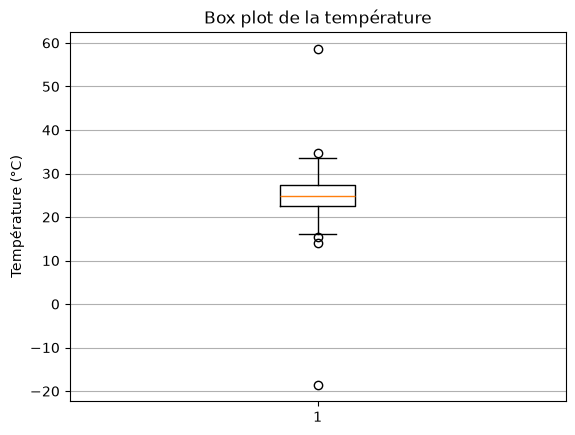

In [13]:
temp_clean = df["temperature"].dropna()

fig, ax = plt.subplots()
ax.boxplot(temp_clean, vert=True)
ax.set_title("Box plot de la température")
ax.set_ylabel("Température (°C)")
ax.grid(axis="y")
plt.show()

## 2) Que représentent les points situés en dehors des moustaches ?

Ce sont les valeurs considérées comme aberrantes (outliers) : des mesures situées bien au-delà de 1.5 fois l'écart interquartile par rapport aux quartiles Q1/Q3.


Ces valeurs doivent être examinées avant d'être supprimées.

## 3) Créer un box plot de la consommation


/tmp/ipykernel_144513/408456939.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(conso_clean, vert=True)


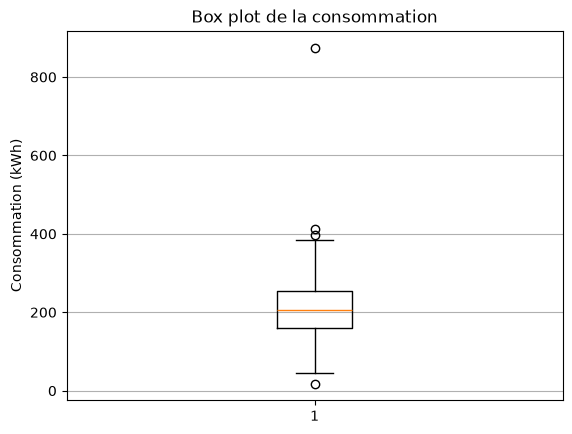

In [14]:
conso_clean = df["consommation"].dropna()

fig, ax = plt.subplots()
ax.boxplot(conso_clean, vert=True)
ax.set_title("Box plot de la consommation")
ax.set_ylabel("Consommation (kWh)")
ax.grid(axis="y")
plt.show()

## 4) A partir des deux box plot, comparer :

### a) la position de la médiane

Pour les deux boxplot la position de la mediane semble etre au milieu de chaque boite

### b) la taille de la boîte 

On a une boîte plus grande pour la consommation indique une dispersion centrale (IQR = Q3 - Q1) plus importante que pour la température. Cela signifie que 50% des mesures de consommation s'étalent sur une plage plus large, reflétant les différences d'efficacité énergétique entre bâtiments. En contraste, la température régulée reste plus concentrée.

### c) la longueur des moustaches 

On Observe des moustaches plus longues traduisent une plus grande étendue des valeurs non aberrantes pour la consommation elles s'étendent de min(données) à max(données) pour chaque variable, dans la limite de [Q1 - 1.5×IQR ; Q3 + 1.5×IQR]. Des moustaches longues indiquent une variabilité plus importante, mais aussi que les variations restent dans une plage acceptable et ne sont pas systématiquement aberrantes.

### d) les valeurs extrêmes.

Le nombre et l'éloignement des points hors moustaches diffèrent entre les deux variables, révélant la qualité des données. Par exemple : la température a plus d'outliers on observe 5 , tandis que la consommation on a que 4 

## 5) La consommation présente-t-elle davantage de dispersion que la température ?

In [15]:
print("Écart-type température :", round(temp_clean.std(), 2))
print("Écart-type consommation :", round(conso_clean.std(), 2))

Écart-type température : 4.06
Écart-type consommation : 72.24


**Oui, la consommation présente davantage de dispersion que la température**, et cela pour plusieurs raisons :

Étant donné que la consommation est exprimée sur une échelle de valeurs beaucoup plus large (kWh, dizaines à centaines) que la température (°C, quelques dizaines de degrés), elle présente généralement une dispersion absolue plus importante.

# Partie 6 – Diagramme circulaire (Pie Chart)

## 1) Réaliser un diagramme pour analyser la répartition des états (OK, ALERTE, ERREUR)

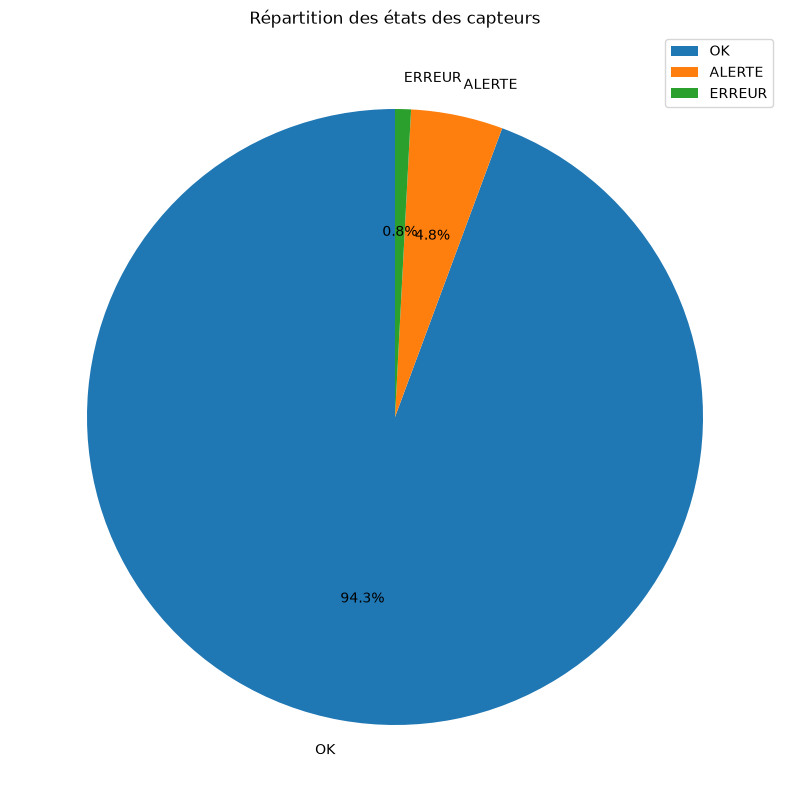

In [20]:
etat_counts = df["etat"].value_counts()

fig, ax = plt.subplots(figsize=(10, 10))
ax.pie(etat_counts.values, labels=etat_counts.index, autopct="%1.1f%%", startangle=90)
ax.set_title("Répartition des états des capteurs")
ax.legend(etat_counts.index, loc="best")
plt.show()

## 2) interpréter la proportion de capteurs OK ; proportion ALERTE ; proportion ERREUR

La grande majorité des capteurs sont à l'état **OK**, ce qui indique un fonctionnement globalement normal du parc de capteurs. Les proportions d'**ALERTE** et d'**ERREUR** sont nettement plus faibles et méritent une surveillance ciblée (capteurs ou bâtiments concernés).

# Partie 7 : Plusieurs courbes sur un même graphique

Construire sur un même graphique « Évolution de la température par bâtiment" » des quatre
bâtiments.

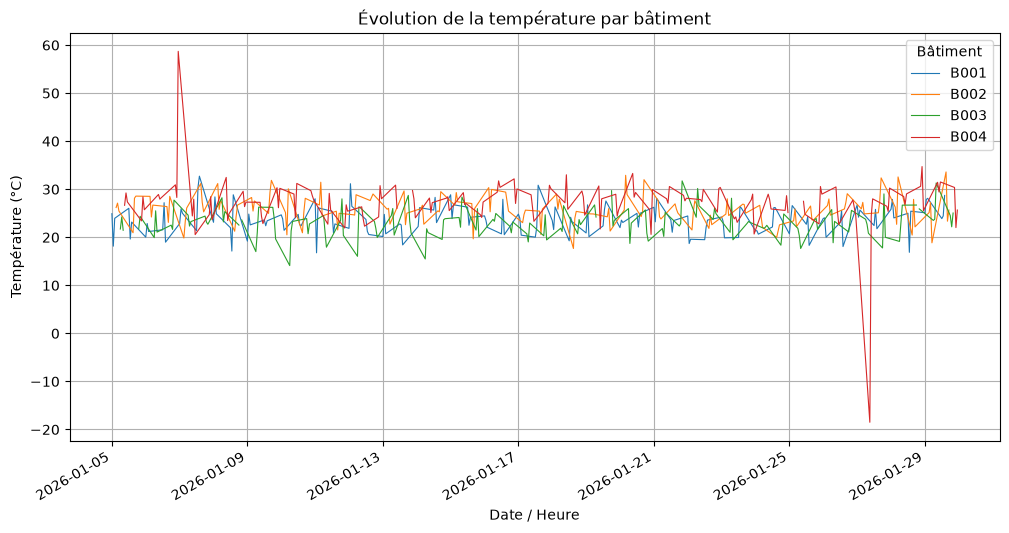

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))

for batiment, groupe in df.groupby("batiment"):
    ax.plot(groupe["date_heure"], groupe["temperature"], label=batiment, linewidth=0.8)

ax.set_title("Évolution de la température par bâtiment")
ax.set_xlabel("Date / Heure")
ax.set_ylabel("Température (°C)")
ax.legend(title="Bâtiment")
ax.grid(True)
fig.autofmt_xdate()
plt.show()

# Partie 8 : Sauvegarde des graphiques

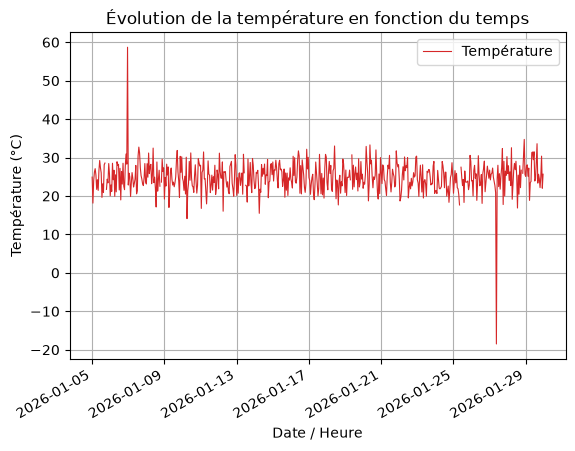

Graphiques sauvegardés dans exports/temperature.png et exports/temperature.pdf


In [23]:
fig, ax = plt.subplots()
ax.plot(df["date_heure"], df["temperature"], color="tab:red", linewidth=0.8)
ax.set_title("Évolution de la température en fonction du temps")
ax.set_xlabel("Date / Heure")
ax.set_ylabel("Température (°C)")
ax.legend(["Température"])
ax.grid(True)
fig.autofmt_xdate()

fig.savefig("/home/adama/atelier_matplotlib_iot/exports/temperature.png", dpi=150, bbox_inches="tight")
fig.savefig("/home/adama/atelier_matplotlib_iot/exports/temperature.pdf", bbox_inches="tight")
plt.show()

print("Graphiques sauvegardés dans exports/temperature.png et exports/temperature.pdf")
